In [2]:
# TP6.2 — Trend, seasonality, and stationarity




In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
import os

ROOT = r"D:\UFR STGI\second Semester\Machine Learning\cours_ia"

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

csv_path = find_file(ROOT, "train.csv")
print("Found train.csv:", csv_path)

if csv_path is None:
    raise FileNotFoundError(f"train.csv not found under {ROOT}. Change ROOT or move train.csv.")

df = pd.read_csv(csv_path, parse_dates=["datetime"])
serie = df.set_index("datetime")["count"].sort_index()
serie = serie.asfreq("h").ffill()

print("serie ready:", serie.shape, "| freq:", serie.index.inferred_freq)


Found train.csv: D:\UFR STGI\second Semester\Machine Learning\cours_ia\IA prédictive\TP6_Series_Temporelles\train.csv
serie ready: (17256,) | freq: h


In [6]:
## Step 1 — Reflection (Additive vs Multiplicative)

#Do peak amplitudes increase when the overall level increases? (=> multiplicative)
# Or do peaks remain roughly stable in amplitude? (=> additive)
# Relevant time scales: daily (24h), weekly (168h)?


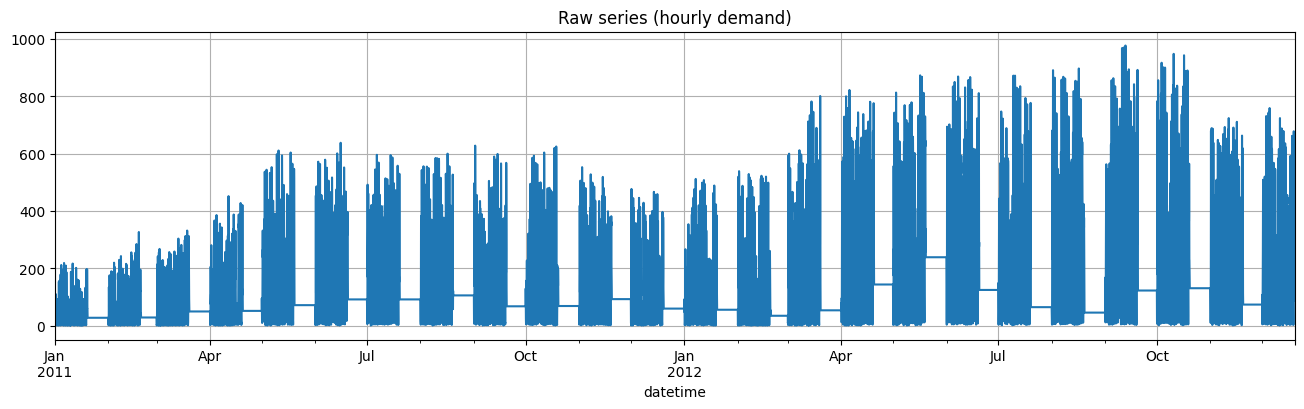

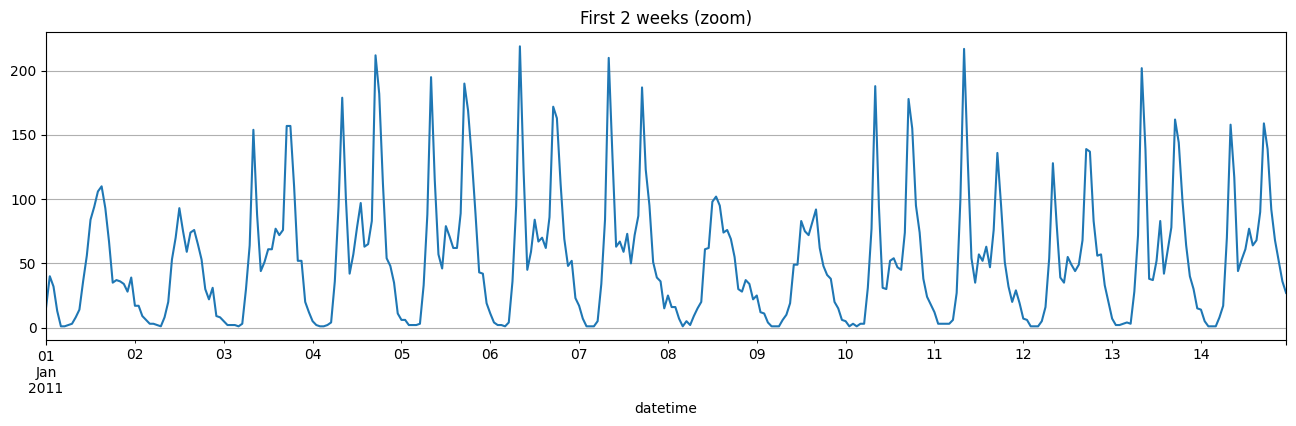

In [7]:
plt.figure(figsize=(16,4))
serie.plot(title="Raw series (hourly demand)")
plt.grid(True)
plt.show()

# Optional: view a short window to inspect amplitude
plt.figure(figsize=(16,4))
serie.iloc[:24*14].plot(title="First 2 weeks (zoom)")
plt.grid(True)
plt.show()


In [8]:
import sys, subprocess

try:
    import statsmodels
    print("statsmodels OK:", statsmodels.__version__)
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "statsmodels"])
    import statsmodels
    print("statsmodels installed:", statsmodels.__version__)


statsmodels OK: 0.14.6


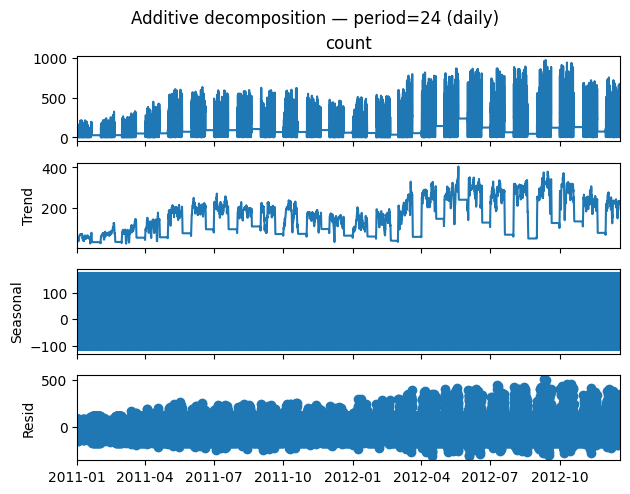

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_add = seasonal_decompose(serie, model="additive", period=24)

result_add.plot()
plt.suptitle("Additive decomposition — period=24 (daily)", y=1.02)
plt.show()


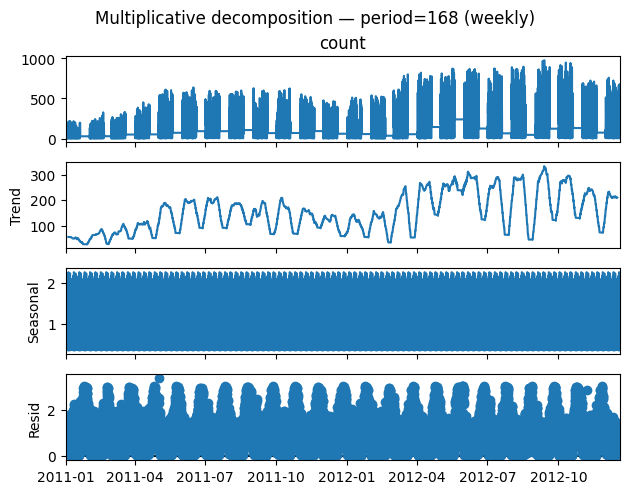

In [10]:
# Multiplicative decomposition needs positive values
# If your series has zeros, use log1p to stabilize and avoid errors.
serie_pos = serie.copy()
if (serie_pos <= 0).any():
    print("Series has zeros or negatives -> using log1p for decomposition.")
    serie_pos = np.log1p(serie_pos)

result_week = seasonal_decompose(serie_pos, model="multiplicative", period=24*7)

result_week.plot()
plt.suptitle("Multiplicative decomposition — period=168 (weekly)", y=1.02)
plt.show()


In [12]:
## Step 2 — Business comment (4–5 lines)

# Trend: does demand grow across 2012?
# Seasonality: daily peaks? weekly weekend patterns?
# Residual: does it look like noise (centered, no structure)?
# Business meaning: implications for fleet regulation / staffing / rebalancing


In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    series = pd.Series(series).dropna()
    stat, pvalue, *_ = adfuller(series)
    print(f"ADF test — {name}")
    print(f"  statistic: {stat:.3f}")
    print(f"  p-value   : {pvalue:.3f}")
    print("  => Stationary?" , "YES (p<0.05)" if pvalue < 0.05 else "NO (p>=0.05)")
    print()


In [14]:
adf_report(serie, "raw series")

# Additive residual
adf_report(result_add.resid, "residual (additive decomposition)")


ADF test — raw series
  statistic: -6.289
  p-value   : 0.000
  => Stationary? YES (p<0.05)

ADF test — residual (additive decomposition)
  statistic: -35.087
  p-value   : 0.000
  => Stationary? YES (p<0.05)



In [17]:
## Step 3 — Interpretation

#If p-value < 0.05: likely stationary
#Is the residual stationary? Why does it matter for AR/ARIMA?
## Step 3 — Interpretation

#If p-value < 0.05: likely stationary
#Is the residual stationary? Why does it matter for AR/ARIMA?


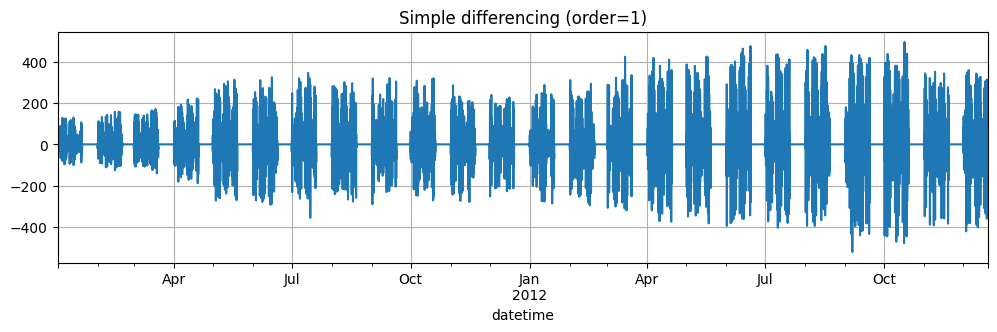

ADF test — first-order difference (diff1)
  statistic: -29.804
  p-value   : 0.000
  => Stationary? YES (p<0.05)



In [18]:
diff1 = serie.diff(1).dropna()

plt.figure(figsize=(12,3))
diff1.plot(title="Simple differencing (order=1)")
plt.grid(True)
plt.show()

adf_report(diff1, "first-order difference (diff1)")


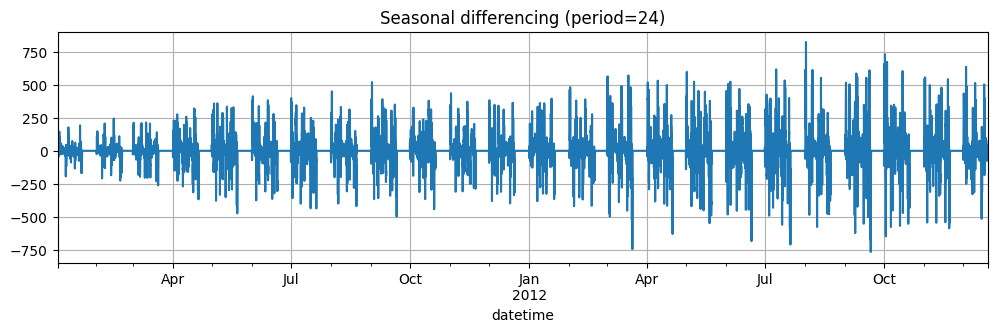

ADF test — seasonal difference (diff24)
  statistic: -20.053
  p-value   : 0.000
  => Stationary? YES (p<0.05)



In [19]:
diff_season = serie.diff(24).dropna()

plt.figure(figsize=(12,3))
diff_season.plot(title="Seasonal differencing (period=24)")
plt.grid(True)
plt.show()

adf_report(diff_season, "seasonal difference (diff24)")


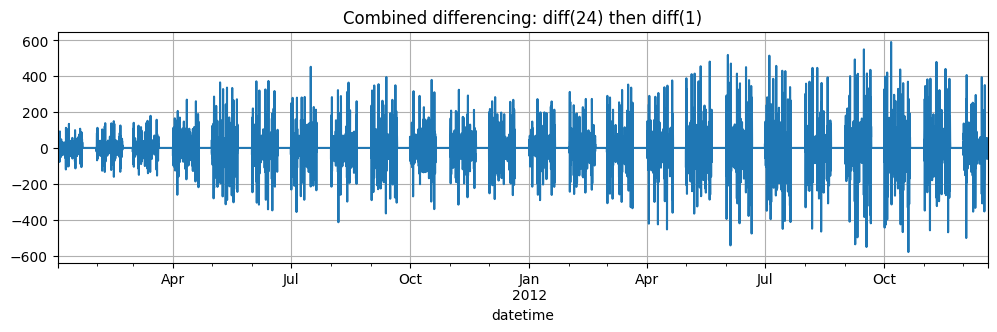

ADF test — combined difference diff(24)+diff(1)
  statistic: -31.349
  p-value   : 0.000
  => Stationary? YES (p<0.05)



In [20]:
diff_both = serie.diff(24).diff(1).dropna()

plt.figure(figsize=(12,3))
diff_both.plot(title="Combined differencing: diff(24) then diff(1)")
plt.grid(True)
plt.show()

adf_report(diff_both, "combined difference diff(24)+diff(1)")


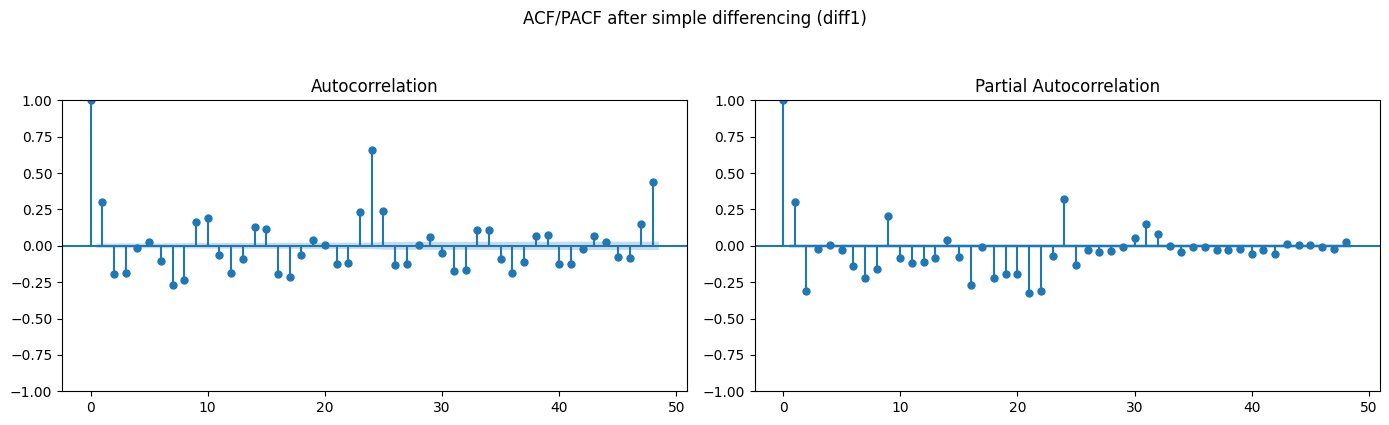

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff1, lags=48, ax=axes[0])
plot_pacf(diff1, lags=48, ax=axes[1], method="ywm")
plt.suptitle("ACF/PACF after simple differencing (diff1)", y=1.05)
plt.tight_layout()
plt.show()


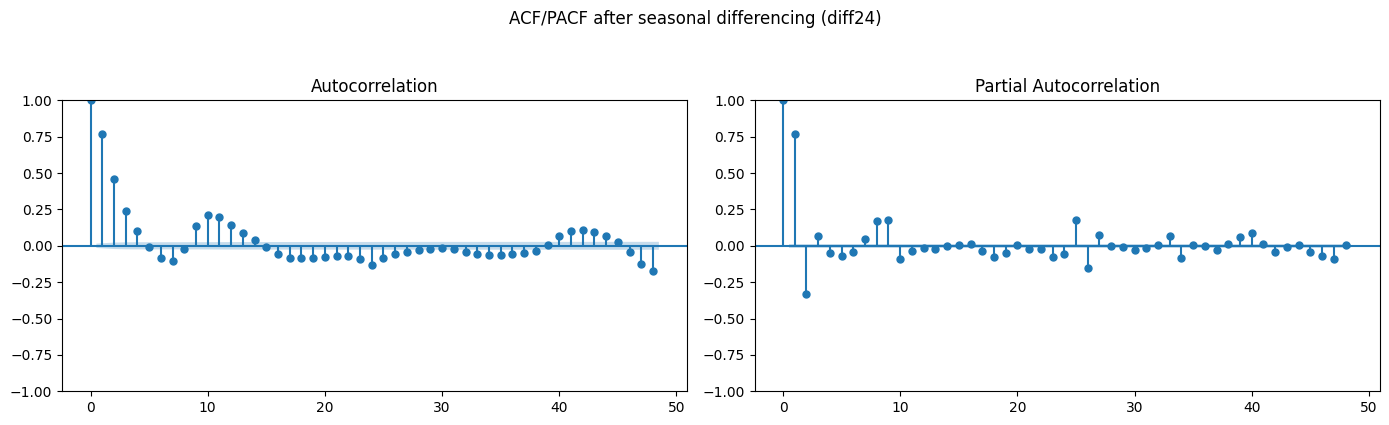

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(diff_season, lags=48, ax=axes[0])
plot_pacf(diff_season, lags=48, ax=axes[1], method="ywm")
plt.suptitle("ACF/PACF after seasonal differencing (diff24)", y=1.05)
plt.tight_layout()
plt.show()


In [24]:
## Step 4.3 — Interpretation

#Did significant lags change after differencing?
# Which AR order (p) and MA order (q) would you try next?
# Any remaining spikes around lag 24 (daily) or 168 (weekly)?


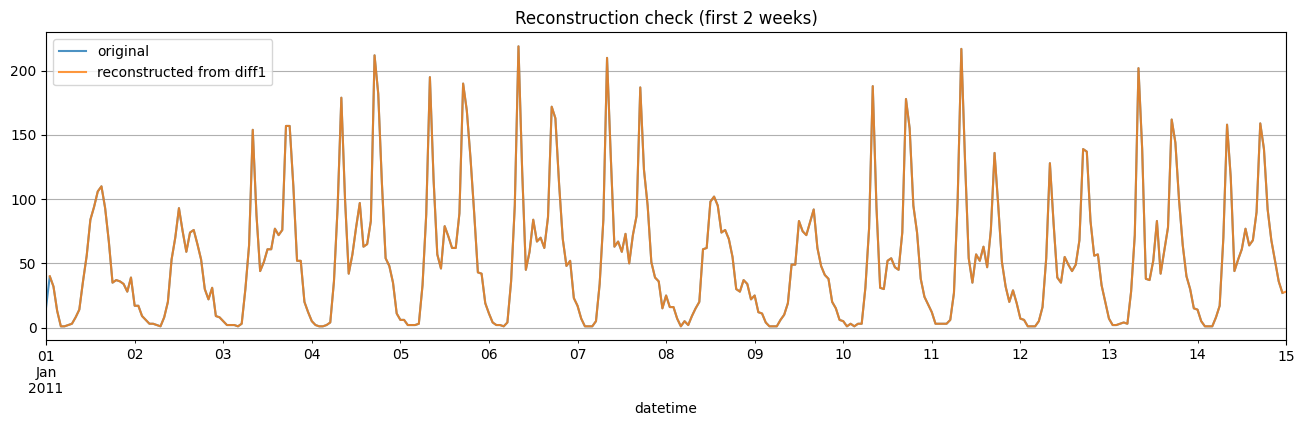

In [25]:
serie_hat = diff1.cumsum() + serie.iloc[0]

plt.figure(figsize=(16,4))
serie.iloc[:24*14].plot(label="original", alpha=0.8)
serie_hat.iloc[:24*14].plot(label="reconstructed from diff1", alpha=0.8)
plt.title("Reconstruction check (first 2 weeks)")
plt.legend()
plt.grid(True)
plt.show()


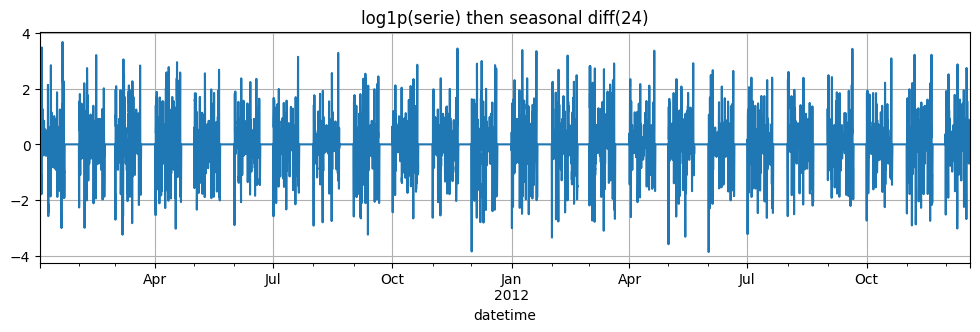

ADF test — log1p + diff(24)
  statistic: -23.600
  p-value   : 0.000
  => Stationary? YES (p<0.05)



In [26]:
serie_log = np.log1p(serie)

diff_log_24 = serie_log.diff(24).dropna()

plt.figure(figsize=(12,3))
diff_log_24.plot(title="log1p(serie) then seasonal diff(24)")
plt.grid(True)
plt.show()

adf_report(diff_log_24, "log1p + diff(24)")


In [27]:
rows = []
def add_row(name, s):
    s = pd.Series(s).dropna()
    stat, pvalue, *_ = adfuller(s)
    rows.append({"series": name, "ADF_stat": stat, "p_value": pvalue})

add_row("raw", serie)
add_row("residual_add", result_add.resid)
add_row("diff1", diff1)
add_row("diff24", diff_season)
add_row("diff24+diff1", diff_both)

adf_table = pd.DataFrame(rows)
display(adf_table)


,series,ADF_stat,p_value
0,raw,-6.289188,3.634530e-08
1,residual_add,-35.087395,0.000000e+00
2,diff1,-29.803920,0.000000e+00
3,diff24,-20.052665,0.000000e+00
4,diff24+diff1,-31.348811,0.000000e+00


In [28]:
## Deliverables — Final synthesis (5 lines)

# Which decomposition (additive vs multiplicative) seems more appropriate and why?
# Which transformation makes the series most stationary (diff1, diff24, both, log)?
# Which lags will matter for AR/ARIMA (24, 168, etc.)?
# What will you use in TP6.3 (chosen differencing + candidate p/q)?
# Business implication: what patterns should the operator anticipate?
